# Case Study: Sentiment Analysis using BERT

**Objective:** Fine-tune a pre-trained BERT model (`bert-base-uncased`) to classify movie reviews as **Positive** or **Negative**.

**Dataset:** IMDB Movie Reviews (50,000 labelled reviews) from Hugging Face Datasets.

**Workflow**
1. Install & import libraries
2. Load and explore the dataset
3. Tokenize text with the BERT tokenizer
4. Fine-tune BERT for sequence classification
5. Evaluate (Accuracy, Precision, Recall, F1, Confusion Matrix)
6. Predict sentiment on custom sentences

> 💡 Run on **Google Colab with GPU** (Runtime → Change runtime type → T4 GPU).

## 1. Install & Import Libraries

In [1]:
!pip install -q transformers datasets evaluate scikit-learn accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.1 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset
from transformers import (BertTokenizerFast, BertForSequenceClassification,
                          TrainingArguments, Trainer, DataCollatorWithPadding)
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             confusion_matrix, classification_report)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)
torch.manual_seed(42)

Using device: cuda


## 2. Load & Explore the Dataset

In [3]:
dataset = load_dataset("stanfordnlp/imdb")
print(dataset)

# Use a subset so training finishes in ~10-15 min on a Colab GPU.
# Increase these numbers (max 25000 each) for higher accuracy.
TRAIN_SIZE, TEST_SIZE = 5000, 2000
train_ds = dataset["train"].shuffle(seed=42).select(range(TRAIN_SIZE))
test_ds  = dataset["test"].shuffle(seed=42).select(range(TEST_SIZE))
print(f"Train: {len(train_ds)} | Test: {len(test_ds)}")

README.md:   0%|          | 0.00/7.81k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 21.0MB            

plain_text/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

plain_text/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 20.5MB            

plain_text/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

plain_text/unsupervised-00000-of-00001.p(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})
Train: 5000 | Test: 2000


,text,sentiment
0,There is no relation at all between Fortier an...,Positive
1,This movie is a great. The plot is very true t...,Positive
2,"George P. Cosmatos' ""Rambo: First Blood Part I...",Negative
3,In the process of trying to establish the audi...,Positive
4,"Yeh, I know -- you're quivering with excitemen...",Negative


/tmp/ipykernel_631/4157468035.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="sentiment", data=df, ax=ax[0], palette="Set2")


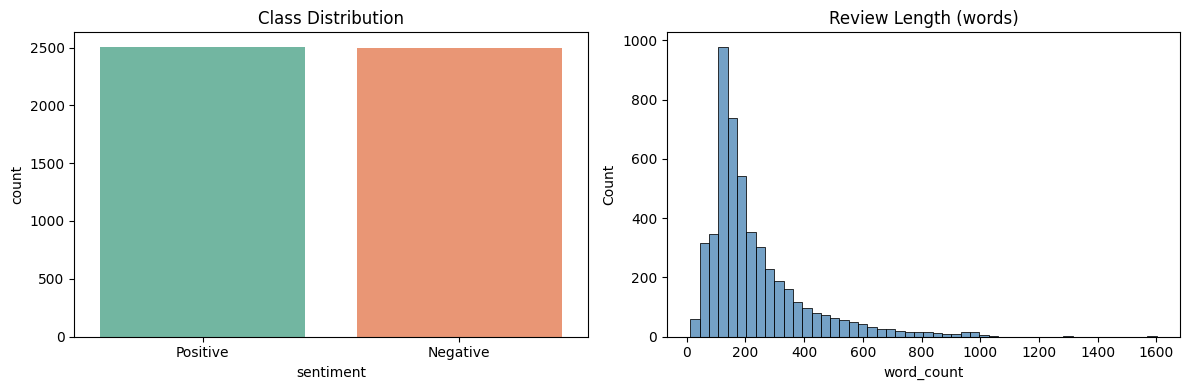

In [4]:
df = pd.DataFrame(train_ds)
df["sentiment"] = df["label"].map({0: "Negative", 1: "Positive"})
df["word_count"] = df["text"].str.split().str.len()
display(df[["text", "sentiment"]].head())

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(x="sentiment", data=df, ax=ax[0], palette="Set2")
ax[0].set_title("Class Distribution")
sns.histplot(df["word_count"], bins=50, ax=ax[1], color="steelblue")
ax[1].set_title("Review Length (words)")
plt.tight_layout(); plt.show()

## 3. Tokenization
BERT needs text converted to token IDs with `[CLS]` and `[SEP]` tokens. Reviews are truncated to 256 tokens (BERT's max is 512).

In [5]:
MODEL_NAME = "bert-base-uncased"
tokenizer = BertTokenizerFast.from_pretrained(MODEL_NAME)

sample = "This movie was absolutely fantastic!"
print("Tokens:", tokenizer.tokenize(sample))
print("IDs   :", tokenizer(sample)["input_ids"])

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Tokens: ['this', 'movie', 'was', 'absolutely', 'fantastic', '!']
IDs   : [101, 2023, 3185, 2001, 7078, 10392, 999, 102]


In [6]:
MAX_LEN = 256
def tokenize(batch):
    return tokenizer(batch["text"], truncation=True, max_length=MAX_LEN)

train_tok = train_ds.map(tokenize, batched=True, remove_columns=["text"])
test_tok  = test_ds.map(tokenize, batched=True, remove_columns=["text"])
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
print(train_tok)

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Dataset({
    features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 5000
})


## 4. Load BERT & Fine-tune
`BertForSequenceClassification` adds a classification layer on top of the `[CLS]` token output.

In [7]:
id2label = {0: "Negative", 1: "Positive"}
label2id = {"Negative": 0, "Positive": 1}
model = BertForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=2, id2label=id2label, label2id=label2id).to(device)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    p, r, f1, _ = precision_recall_fscore_support(labels, preds, average="binary")
    return {"accuracy": accuracy_score(labels, preds), "precision": p, "recall": r, "f1": f1}

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [9]:
args = TrainingArguments(
    output_dir="bert-sentiment",
    num_train_epochs=2,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_steps=60,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    logging_steps=50,
    fp16=torch.cuda.is_available(),
    report_to="none",
)

trainer = Trainer(model=model, args=args,
                  train_dataset=train_tok, eval_dataset=test_tok,
                  processing_class=tokenizer, data_collator=data_collator,
                  compute_metrics=compute_metrics)
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.313144,0.368244,0.855000,0.787217,0.973000,0.870304
2,0.180911,0.261605,0.903000,0.878759,0.935000,0.906008


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

TrainOutput(global_step=626, training_loss=0.3010874137329979, metrics={'train_runtime': 168.1373, 'train_samples_per_second': 59.475, 'train_steps_per_second': 3.723, 'total_flos': 1315555276800000.0, 'train_loss': 0.3010874137329979, 'epoch': 2.0})

## 5. Evaluation

In [10]:
results = trainer.evaluate()
for k, v in results.items():
    print(f"{k:25s}: {v:.4f}" if isinstance(v, float) else f"{k:25s}: {v}")

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.180911,0.261605,2,0.903000,0.878759,0.935000,0.906008


eval_loss                : 0.2616
eval_accuracy            : 0.9030
eval_precision           : 0.8788
eval_recall              : 0.9350
eval_f1                  : 0.9060


              precision    recall  f1-score   support

    Negative       0.93      0.87      0.90      1000
    Positive       0.88      0.94      0.91      1000

    accuracy                           0.90      2000
   macro avg       0.90      0.90      0.90      2000
weighted avg       0.90      0.90      0.90      2000



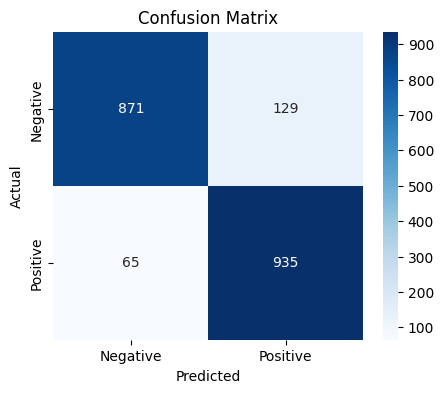

In [11]:
pred_out = trainer.predict(test_tok)
y_pred = np.argmax(pred_out.predictions, axis=-1)
y_true = pred_out.label_ids

print(classification_report(y_true, y_pred, target_names=["Negative", "Positive"]))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Negative", "Positive"], yticklabels=["Negative", "Positive"])
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.title("Confusion Matrix")
plt.show()

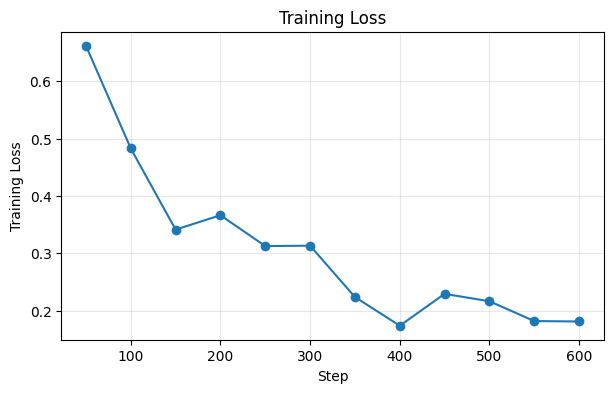

In [12]:
# Training loss curve
logs = pd.DataFrame(trainer.state.log_history)
loss = logs.dropna(subset=["loss"])
plt.figure(figsize=(7, 4))
plt.plot(loss["step"], loss["loss"], marker="o")
plt.xlabel("Step"); plt.ylabel("Training Loss"); plt.title("Training Loss")
plt.grid(alpha=0.3); plt.show()

## 6. Predict Sentiment on Custom Text

In [13]:
def predict_sentiment(texts):
    model.eval()
    enc = tokenizer(texts, truncation=True, max_length=MAX_LEN,
                    padding=True, return_tensors="pt").to(model.device)
    with torch.no_grad():
        probs = torch.softmax(model(**enc).logits, dim=-1).cpu().numpy()
    for t, p in zip(texts, probs):
        label = id2label[int(p.argmax())]
        print(f"[{label:8s} | {p.max()*100:5.1f}%]  {t}")

predict_sentiment([
    "This movie was an absolute masterpiece, I loved every minute of it!",
    "Terrible acting and a boring plot. Complete waste of time.",
    "The visuals were stunning but the story felt a bit weak.",
    "I would definitely recommend this film to my friends.",
    "Worst experience ever, I walked out halfway through.",
])

[Positive |  99.1%]  This movie was an absolute masterpiece, I loved every minute of it!
[Negative |  98.6%]  Terrible acting and a boring plot. Complete waste of time.
[Negative |  94.0%]  The visuals were stunning but the story felt a bit weak.
[Positive |  98.4%]  I would definitely recommend this film to my friends.
[Negative |  89.7%]  Worst experience ever, I walked out halfway through.


## 7. Save the Model (optional)

In [14]:
trainer.save_model("bert-sentiment-final")
tokenizer.save_pretrained("bert-sentiment-final")
print("Model saved to ./bert-sentiment-final")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to ./bert-sentiment-final


## Conclusion
- Fine-tuned **BERT (bert-base-uncased)** on IMDB reviews for binary sentiment classification.
- With only 5,000 training samples and 2 epochs, BERT typically reaches **~88–91% accuracy**, showing the strength of transfer learning.
- BERT's bidirectional attention captures context (e.g., negation like *"not good"*) far better than bag-of-words models.

**Possible improvements:** train on the full 25k dataset, use `max_length=512`, try DistilBERT (faster) or RoBERTa (more accurate), and tune the learning rate.